In [1]:
import numpy as np

from metalib.indicators import *
from metalib.utils import load_hist_data
import matplotlib.pyplot as plt
import pandas as pd

price_df = load_hist_data("EURUSD", 2023).resample("1h", closed="right", label="right").agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
})

close = price_df.loc[:,"close"]

C:\Users\Hermes\miniconda3\envs\adonys\Lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [2]:
close = pd.read_parquet("C_USDJPY.parquet").set_index("date")[["value"]]
close.columns = ["open"]

In [3]:
to_w0 = get_last_monday_6pm_open_ffill(price_df, price_df.index, i=0)
to_w1 = get_last_monday_6pm_open_ffill(price_df, price_df.index, i=1)
to_w2 = get_last_monday_6pm_open_ffill(price_df, price_df.index, i=2)

to_m0 = get_second_monday_open_ffill(price_df, price_df.index, i=0)
to_m1 = get_second_monday_open_ffill(price_df, price_df.index, i=1)
to_m2 = get_second_monday_open_ffill(price_df, price_df.index, i=2)

In [ ]:
weekly_levels

In [4]:
to_w0

time
2023-01-01 18:00:00        NaN
2023-01-01 19:00:00        NaN
2023-01-01 20:00:00        NaN
2023-01-01 21:00:00        NaN
2023-01-01 22:00:00        NaN
                        ...   
2023-12-29 13:00:00    1.10256
2023-12-29 14:00:00    1.10256
2023-12-29 15:00:00    1.10256
2023-12-29 16:00:00    1.10256
2023-12-29 17:00:00    1.10256
Freq: h, Name: open, Length: 8688, dtype: float64

In [8]:
indicators = pd.DataFrame({"to_w0": to_w0, "to_w1": to_w1, "to_w2": to_w2, "close": close})

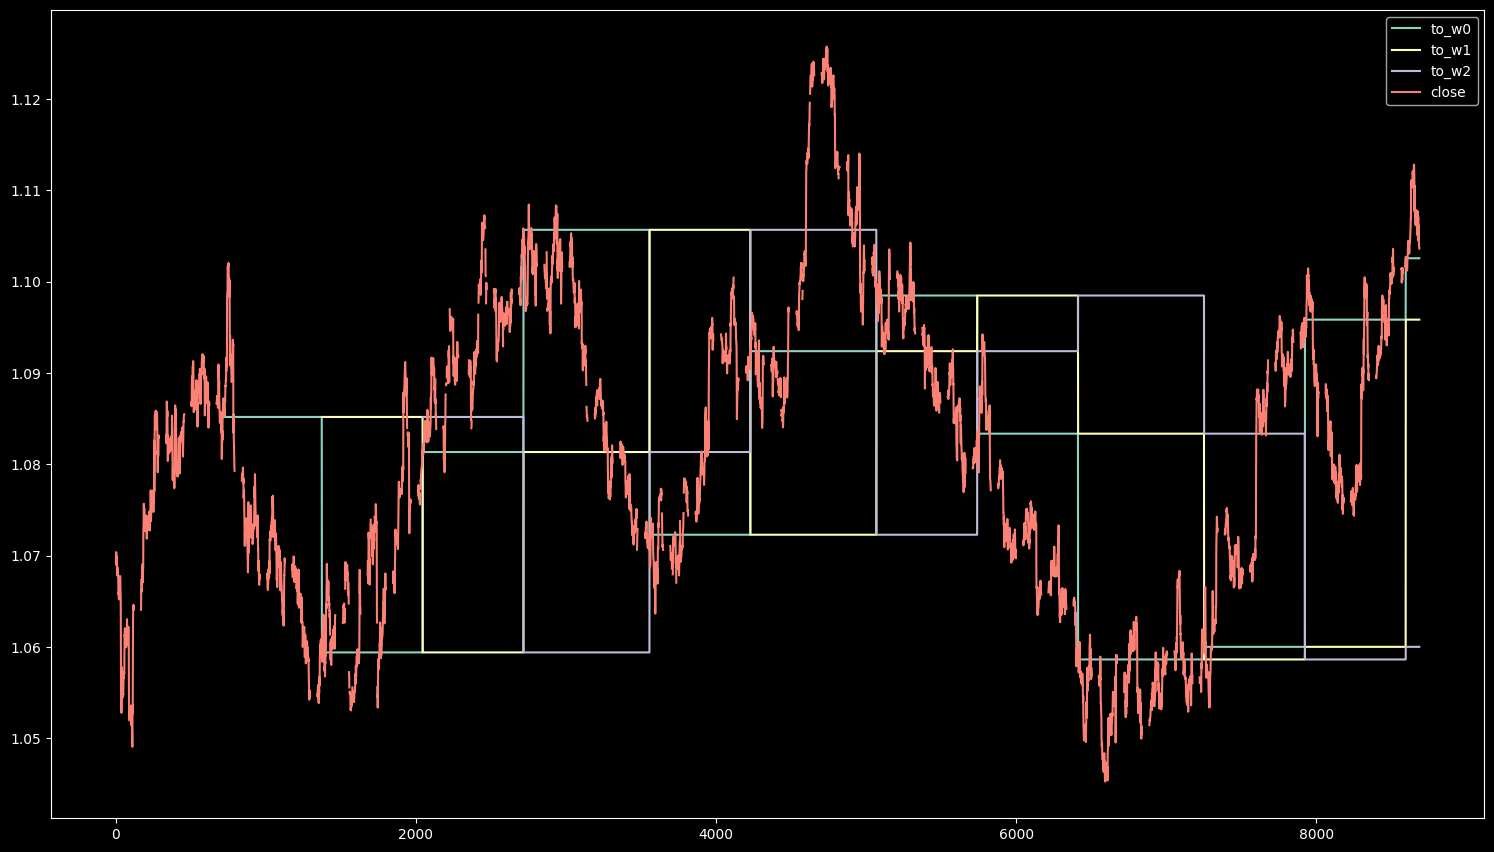

In [9]:
fig, ax = plt.subplots()
fig.set_size_inches(18.5, 10.5)

indicators.reset_index(drop=True).plot(ax=ax)
plt.legend()
plt.show()

In [13]:
def momentum_score(returns: pd.Series, window: int = 300) -> pd.DataFrame:
    """
    returns : log-returns à 15m ou 1h
    Retourne : DataFrame avec colonnes [alpha, se, t_stat, score]
    """
    out = pd.DataFrame(index=returns.index,
                       columns=['alpha', 'se', 't_stat', 'score'])

    for t in range(window, len(returns)):
        r = returns.iloc[t-window:t].values
        r_lag, r_curr = r[:-1], r[1:]

        # OLS sans intercept
        denom = (r_lag ** 2).sum()
        if denom == 0:
            continue
        alpha = (r_lag * r_curr).sum() / denom

        # Résidus + SE Newey-West (lag=1)
        eps = r_curr - alpha * r_lag
        sigma2 = (eps ** 2).mean()
        se = np.sqrt(sigma2 / denom)

        t_stat = alpha / se if se > 0 else 0
        score = np.sign(alpha) * min(abs(t_stat), 4) / 4

        out.iloc[t] = [alpha, se, t_stat, score]

    return out

In [15]:
returns = close.apply(np.log).diff()

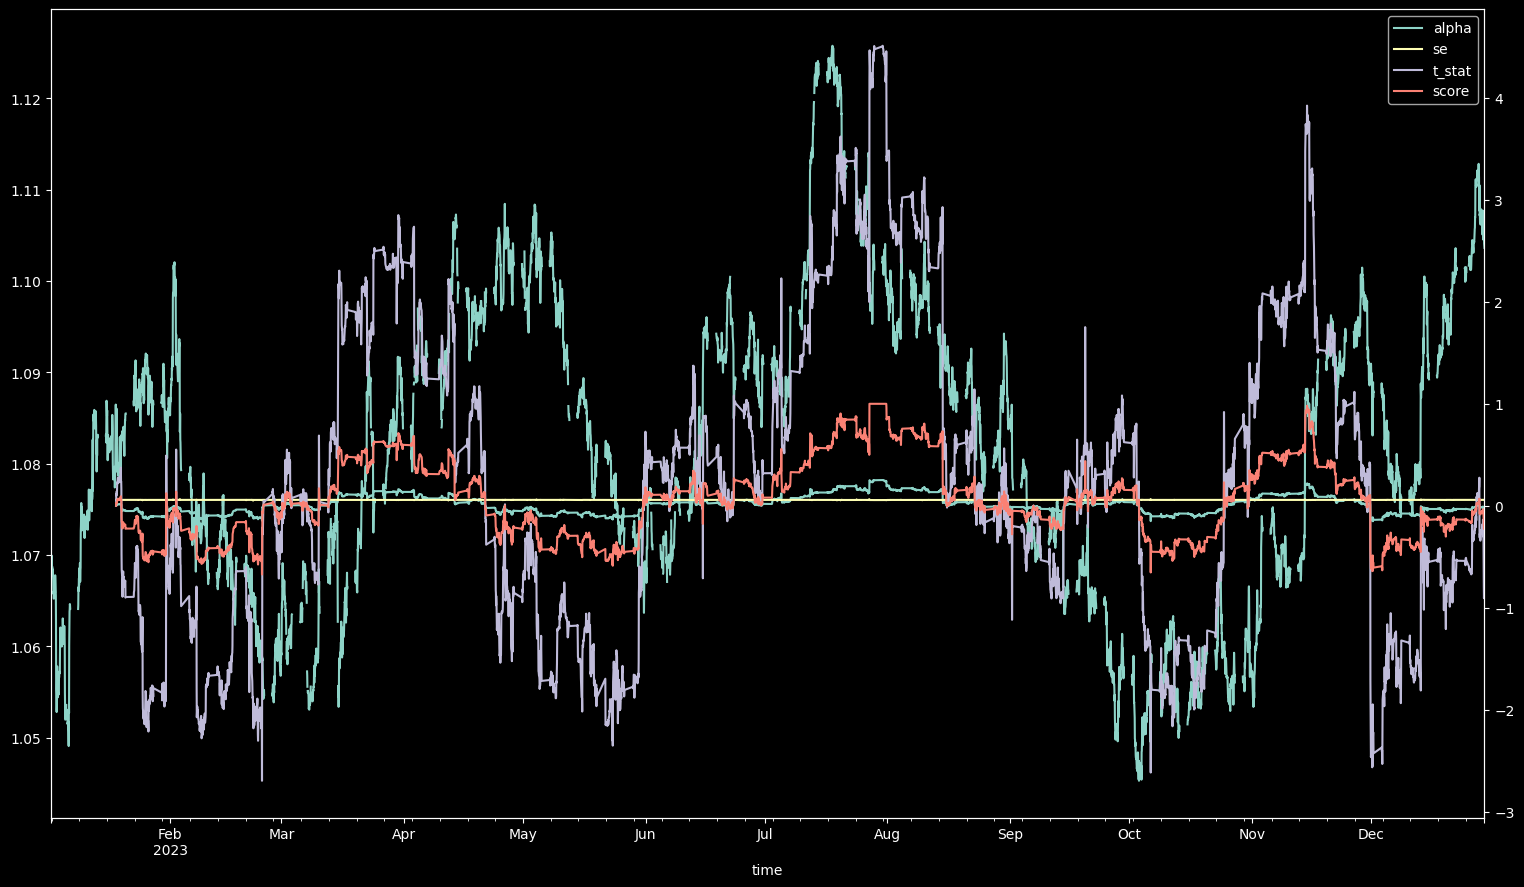

In [25]:
fig, ax = plt.subplots()
fig.set_size_inches(18.5, 10.5)
ax1 = ax.twinx()

close.plot(ax=ax)
momentum_score(returns.dropna(), window=300).plot(ax=ax1)
ax1.legend()

In [18]:
returns

time
2023-01-01 18:00:00         NaN
2023-01-01 19:00:00    0.000654
2023-01-01 20:00:00    0.000364
2023-01-01 21:00:00   -0.000897
2023-01-01 22:00:00   -0.000440
                         ...   
2023-12-29 13:00:00   -0.000335
2023-12-29 14:00:00   -0.000552
2023-12-29 15:00:00   -0.000978
2023-12-29 16:00:00   -0.000190
2023-12-29 17:00:00   -0.000245
Freq: h, Name: close, Length: 8688, dtype: float64